# Phase 1: Import Libraries & Load Data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set the working directory
os.chdir("C:/Users/Pujitha/Desktop/python practice/ml/day-10")

# Load Dataset
df = pd.read_csv("Electronic_sales_Sep2023-Sep2024.csv")

# Display first 5 rows
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


# Phase 2: Data Understanding

In [10]:
# Shape
print("Rows and Columns:", df.shape)

# Information
df.info()

# Statistical Summary
df.describe()

# Missing Values
df.isnull().sum()

Rows and Columns: (20000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  str    
 3   Loyalty Member     20000 non-null  str    
 4   Product Type       20000 non-null  str    
 5   SKU                20000 non-null  str    
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  str    
 8   Payment Method     20000 non-null  str    
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  str    
 13  Shipping Type      20000 non-null  str    
 14  Add-ons Purchased  15132 non-null  str    
 15  Add-on Total       20000 non-null  float64
dtypes: 

Customer ID             0
Age                     0
Gender                  1
Loyalty Member          0
Product Type            0
SKU                     0
Rating                  0
Order Status            0
Payment Method          0
Total Price             0
Unit Price              0
Quantity                0
Purchase Date           0
Shipping Type           0
Add-ons Purchased    4868
Add-on Total            0
dtype: int64

# Phase 3: Data Cleaning

In [14]:
# Check duplicates
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Missing Values
df['Add-ons Purchased'] = df['Add-ons Purchased'].fillna('None')

# Convert Purchase Date
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Verify
df.info()

Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        20000 non-null  int64         
 1   Age                20000 non-null  int64         
 2   Gender             19999 non-null  str           
 3   Loyalty Member     20000 non-null  str           
 4   Product Type       20000 non-null  str           
 5   SKU                20000 non-null  str           
 6   Rating             20000 non-null  int64         
 7   Order Status       20000 non-null  str           
 8   Payment Method     20000 non-null  str           
 9   Total Price        20000 non-null  float64       
 10  Unit Price         20000 non-null  float64       
 11  Quantity           20000 non-null  int64         
 12  Purchase Date      20000 non-null  datetime64[us]
 13  Shipping Type      20000 non-null  str           
 14 

# Phase 4: Exploratory Data Analysis

# 1. Product Type Distribution

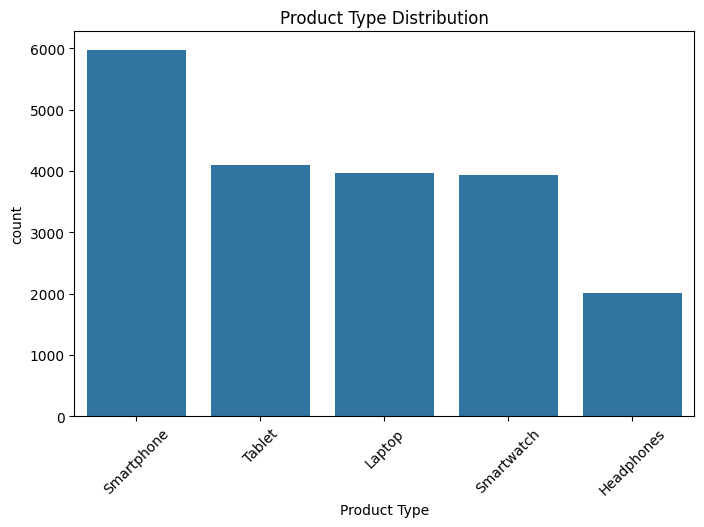

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Product Type')
plt.title("Product Type Distribution")
plt.xticks(rotation=45)
plt.show()

# 2. Gender Distribution

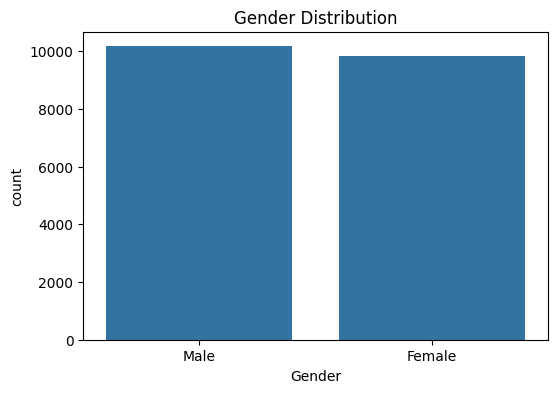

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender')
plt.title("Gender Distribution")
plt.show()

# 3. Total Sales by Product Type

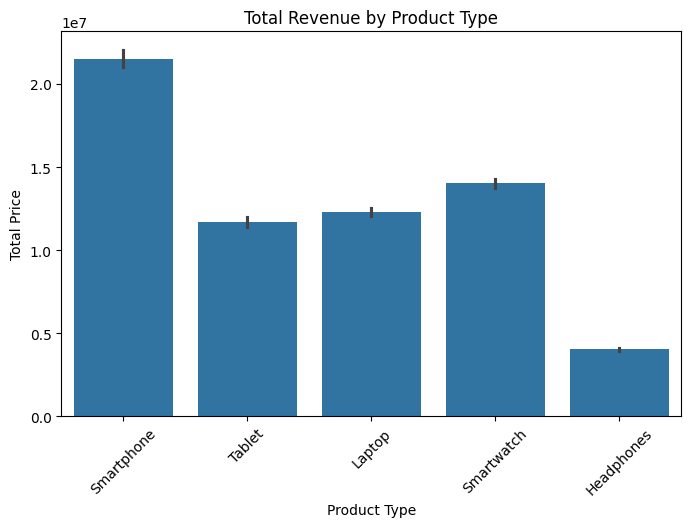

In [17]:

plt.figure(figsize=(8,5))
sns.barplot(data=df,
            x='Product Type',
            y='Total Price',
            estimator=sum)

plt.title("Total Revenue by Product Type")
plt.xticks(rotation=45)
plt.show()

# 4. Rating Distribution

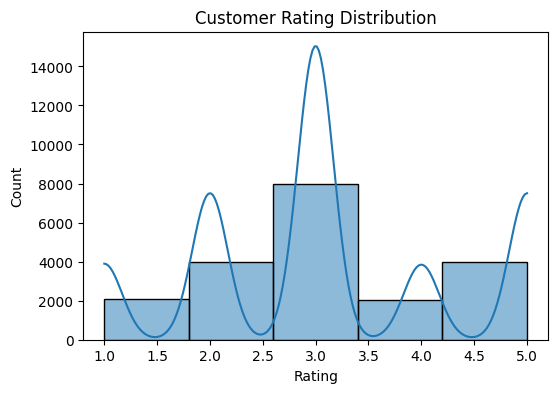

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df['Rating'], bins=5, kde=True)
plt.title("Customer Rating Distribution")
plt.show()

# 5. Payment Method Analysis

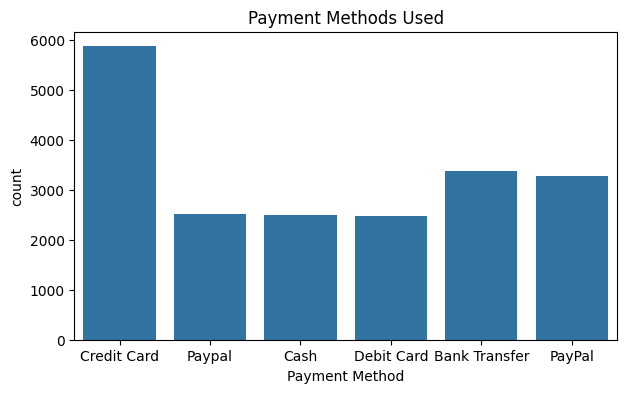

In [19]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Payment Method')
plt.title("Payment Methods Used")
plt.show()

# 6. Loyalty Member Analysis

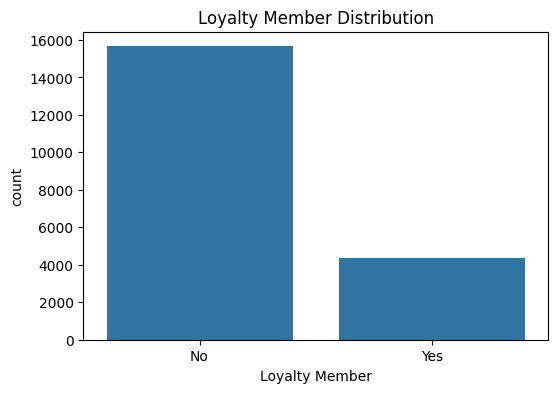

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Loyalty Member')
plt.title("Loyalty Member Distribution")
plt.show()

# 7. Correlation Heatmap

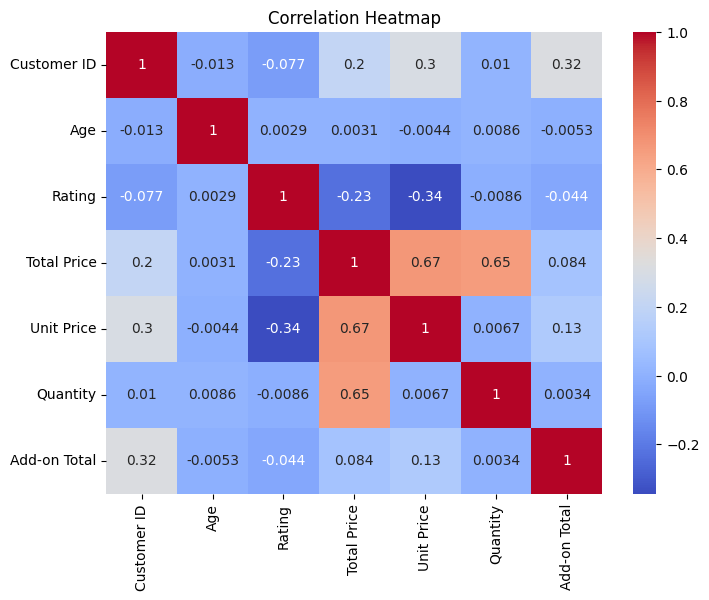

In [21]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# 8. Monthly Sales Trend

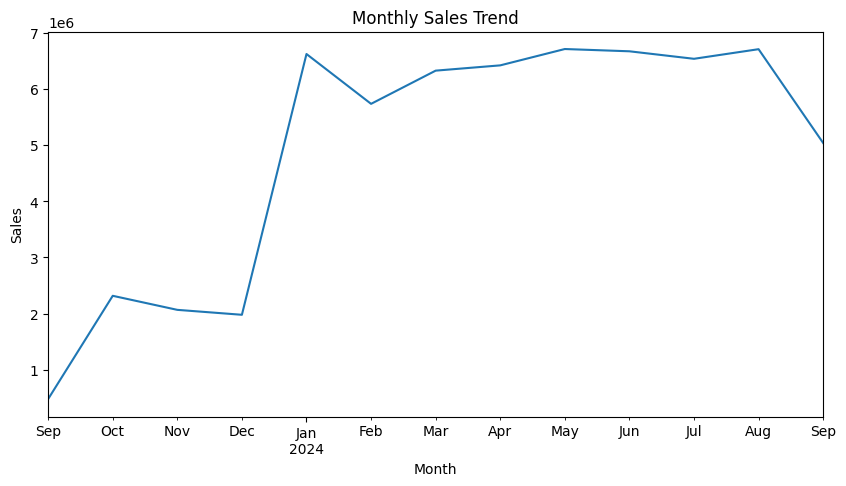

In [22]:
df['Month'] = df['Purchase Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Price'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Insights for ML Modeling (Markdown Cell at Bottom)

# Insights for ML Modeling

1. Features such as Quantity, Unit Price and Total Price are highly related and may create multicollinearity.

2. Total Price can be considered as a target variable for sales prediction models.

3. Product Type, Payment Method, Loyalty Member, Shipping Type and Gender require encoding before modeling.

4. Missing values in Add-ons Purchased were handled appropriately.

5. Correlation analysis should be used to remove redundant features before model training.

6. Potential Feature Engineering:
   - Month from Purchase Date
   - Year from Purchase Date
   - Customer Purchase Frequency
   - Average Customer Rating

7. Suitable Models:
   - Linear Regression
   - Random Forest Regressor
   - XGBoost Regressor

8. Data scaling may be required for linear models but not for tree-based models.